# 02b - Preprocessing via Sélection par Modèles
## Objectif : Sélectionner les features via RFE, Forward et Backward Selection

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import json
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

print("✅ Imports OK")

✅ Imports OK


In [116]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

result = client.query("SELECT version()")
print(f"✅ ClickHouse connecté — version : {result.result_rows[0][0]}")

✅ ClickHouse connecté — version : 23.8.16.16


In [117]:
df = client.query_df("""
SELECT
    d.Year                               AS year,
    d.Month                              AS month,
    d.Quarter                            AS quarter,
    SUM(f.LinePrice)                     AS total_sales,
    SUM(f.Quantity)                      AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)       AS nb_documents,
    COUNT(DISTINCT f.ClientSK)           AS nb_clients,
    COUNT(DISTINCT f.ItemSK)             AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)        AS nb_warehouses,
    AVG(f.DiscountPercentage)            AS avg_discount,
    SUM(f.DiscountAmount)                AS total_discount,
    SUM(f.CostPrice)                     AS total_cost,
    SUM(f.LinePrice - f.CostPrice)       AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f"✅ {len(df)} mois chargés — shape : {df.shape}")
df.head()

✅ 51 mois chargés — shape : (51, 15)


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,total_cost,total_marge,date
0,2021,3,1,404.06,6,1,1,6,1,2,15.00,60.61,334.97,69.09,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,3225,9,3,9.28,"44,802.24","604,390.30","-12,982.36",2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,3327,9,3,9.69,"36,225.76","677,038.55","-100,941.11",2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,3497,9,3,7.93,"40,184.68","683,998.33","-3,784.44",2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,3264,9,4,9.09,"47,939.71","638,230.20","12,559.36",2022-04-01


## 1. Nettoyage — Suppression des mois incomplets

In [118]:
print(f"Avant nettoyage : {len(df)} mois")
print(f"\nMois incomplets :")
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f"\nAprès nettoyage : {len(df)} mois")
print(f"Période : {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Avant nettoyage : 51 mois

Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


## 2. Feature Engineering — Création de toutes les variables candidates

In [119]:
df_ml = df.copy()

# ── Variables temporelles ─────────────────────────────────────
df_ml['semester']    = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# ── Lag features ──────────────────────────────────────────────
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_2']  = df_ml['total_sales'].shift(2)
df_ml['lag_3']  = df_ml['total_sales'].shift(3)
df_ml['lag_6']  = df_ml['total_sales'].shift(6)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)

# ── Rolling features ──────────────────────────────────────────
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()
df_ml['rolling_mean_6'] = df_ml['total_sales'].shift(1).rolling(6).mean()
df_ml['rolling_std_3']  = df_ml['total_sales'].shift(1).rolling(3).std()
df_ml['rolling_max_3']  = df_ml['total_sales'].shift(1).rolling(3).max()
df_ml['rolling_min_3']  = df_ml['total_sales'].shift(1).rolling(3).min()

# ── Variables de croissance ───────────────────────────────────
#df_ml['growth_1m']  = df_ml['total_sales'].pct_change(1)
#df_ml['growth_yoy'] = df_ml['total_sales'].pct_change(12)

# ── Supprimer NaN ─────────────────────────────────────────────
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"✅ Dataset prêt : {df_ml.shape}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")
print(f"\nVariables candidates : {df_ml.shape[1] - 2}")  # -2 pour date et total_sales
df_ml.head()


✅ Dataset prêt : (37, 29)
Période : Jan 2023 → Jan 2026

Variables candidates : 27


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,...,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,rolling_max_3,rolling_min_3
0,2023,1,1,"1,037,923.46",16598,1380,223,4963,9,4,...,"985,659.74","957,116.13","937,241.06","787,031.57","591,407.94","960,005.64","929,543.20","24,338.32","985,659.74","937,241.06"
1,2023,2,1,"939,044.09",15537,1280,227,4505,9,4,...,"1,037,923.46","985,659.74","957,116.13","847,028.15","576,097.45","993,566.44","971,358.52","40,979.79","1,037,923.46","957,116.13"
2,2023,3,1,"948,325.78",15961,1392,240,4353,9,4,...,"939,044.09","1,037,923.46","985,659.74","1,063,182.57","680,213.89","987,542.43","986,694.51","49,466.56","1,037,923.46","939,044.09"
3,2023,4,2,"913,161.55",17831,1237,235,3862,9,4,...,"948,325.78","939,044.09","1,037,923.46","937,241.06","650,789.55","975,097.78","967,551.71","54,606.20","1,037,923.46","939,044.09"
4,2023,5,2,"1,184,666.29",20290,1514,246,4933,9,5,...,"913,161.55","948,325.78","939,044.09","957,116.13","734,335.68","933,510.47","963,538.46","18,223.52","948,325.78","913,161.55"


## 3. Définition des features candidates et split temporel

In [120]:
TARGET = 'total_sales'

# Variables contemporaines — inconnues au moment de prédire
CONTEMPORAINES = [
    'total_quantity',  # ← connu seulement quand la vente est faite
    'nb_produits',     # ← idem
    'nb_clients',      # ← idem
    'nb_documents',    # ← idem
    'nb_regions',      # ← idem
    'nb_warehouses',   # ← idem
    'avg_discount',    # ← idem
    'total_discount',  # ← idem
    'total_cost',      # ← idem
    'total_marge',     # ← idem
]

ALL_FEATURES = [c for c in df_ml.columns
                if c not in [
                    'date', TARGET,
                     ] + CONTEMPORAINES ]

X_all = df_ml[ALL_FEATURES]
y_all = df_ml[TARGET]

# Split D'ABORD
split_idx  = int(len(df_ml) * 0.9)

df_train = df_ml.iloc[:split_idx].copy()
df_test  = df_ml.iloc[split_idx:].copy()

# Vérification — aucune donnée future dans le train
print(f"Train : {df_train['date'].min().strftime('%b %Y')} → {df_train['date'].max().strftime('%b %Y')}")
print(f"Test  : {df_test['date'].min().strftime('%b %Y')} → {df_test['date'].max().strftime('%b %Y')}")

X_tr = df_train[ALL_FEATURES]
X_te = df_test[ALL_FEATURES]
y_tr = df_train[TARGET]
y_te = df_test[TARGET]

# Normalisation
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f"\n✅ Split correct — pas de data leakage")
print(f"X_tr shape : {X_tr.shape}")
print(f"X_te shape : {X_te.shape}")

print(f"✅ {len(ALL_FEATURES)} features candidates :")
for f in ALL_FEATURES:
    print(f"  • {f}")
print(f"\nTrain : {len(X_tr)} mois")
print(f"Test  : {len(X_te)} mois ({split_date.strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')})")

Train : Jan 2023 → Sep 2025
Test  : Oct 2025 → Jan 2026

✅ Split correct — pas de data leakage
X_tr shape : (33, 17)
X_te shape : (4, 17)
✅ 17 features candidates :
  • year
  • month
  • quarter
  • semester
  • is_summer
  • is_end_year
  • is_january
  • lag_1
  • lag_2
  • lag_3
  • lag_6
  • lag_12
  • rolling_mean_3
  • rolling_mean_6
  • rolling_std_3
  • rolling_max_3
  • rolling_min_3

Train : 33 mois
Test  : 4 mois (Oct 2025 → Jan 2026)


## 4. RFE — Recursive Feature Elimination

In [121]:
print("="*55)
print("1️⃣  RFE — Recursive Feature Elimination")
print("="*55)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=8)
rfe.fit(X_tr_sc, y_tr)

features_rfe = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES))
                if rfe.support_[i]]
pred_rfe     = rfe.predict(X_te_sc)
mae_rfe      = mean_absolute_error(y_te, pred_rfe)
mape_rfe     = np.mean(np.abs((y_te - pred_rfe) / y_te)) * 100
r2_rfe       = r2_score(y_te, pred_rfe)
bias_rfe     = np.mean(pred_rfe - y_te)

print(f"\nFeatures sélectionnées ({len(features_rfe)}) :")
for f in features_rfe:
    print(f"  • {f}")
print(f"\nMAE  : {mae_rfe:>12,.0f} DT")
print(f"MAPE : {mape_rfe:>12.2f} %")
print(f"R²   : {r2_rfe:>12.4f}")
print(f"Biais: {bias_rfe:>12,.0f} DT")

1️⃣  RFE — Recursive Feature Elimination

Features sélectionnées (8) :
  • year
  • month
  • semester
  • is_summer
  • lag_2
  • lag_3
  • lag_6
  • rolling_mean_6

MAE  :      186,914 DT
MAPE :        12.63 %
R²   :      -0.7539
Biais:      -13,716 DT


## 5. Forward Selection

In [122]:
print("="*55)
print("2️⃣  Forward Selection")
print("="*55)

sfs_fwd = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=8,
    direction='forward',
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3)
)
sfs_fwd.fit(X_tr_sc, y_tr)

features_fwd = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES))
                if sfs_fwd.get_support()[i]]
mask_fwd     = sfs_fwd.get_support()
pred_fwd     = LinearRegression().fit(
                   X_tr_sc[:, mask_fwd], y_tr
               ).predict(X_te_sc[:, mask_fwd])

mae_fwd  = mean_absolute_error(y_te, pred_fwd)
mape_fwd = np.mean(np.abs((y_te - pred_fwd) / y_te)) * 100
r2_fwd   = r2_score(y_te, pred_fwd)
bias_fwd = np.mean(pred_fwd - y_te)

print(f"\nFeatures sélectionnées ({len(features_fwd)}) :")
for f in features_fwd:
    print(f"  • {f}")
print(f"\nMAE  : {mae_fwd:>12,.0f} DT")
print(f"MAPE : {mape_fwd:>12.2f} %")
print(f"R²   : {r2_fwd:>12.4f}")
print(f"Biais: {bias_fwd:>12,.0f} DT")

2️⃣  Forward Selection

Features sélectionnées (8) :
  • year
  • quarter
  • is_end_year
  • is_january
  • lag_2
  • lag_6
  • rolling_mean_6
  • rolling_std_3

MAE  :       91,480 DT
MAPE :         6.25 %
R²   :       0.7171
Biais:       -9,661 DT


## 6. Backward Elimination

In [123]:
print("="*55)
print("3️⃣  Backward Elimination")
print("="*55)

sfs_bwd = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=8,
    direction='backward',
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3)
)
sfs_bwd.fit(X_tr_sc, y_tr)

features_bwd = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES))
                if sfs_bwd.get_support()[i]]
mask_bwd     = sfs_bwd.get_support()
pred_bwd     = LinearRegression().fit(
                   X_tr_sc[:, mask_bwd], y_tr
               ).predict(X_te_sc[:, mask_bwd])

mae_bwd  = mean_absolute_error(y_te, pred_bwd)
mape_bwd = np.mean(np.abs((y_te - pred_bwd) / y_te)) * 100
r2_bwd   = r2_score(y_te, pred_bwd)
bias_bwd = np.mean(pred_bwd - y_te)

print(f"\nFeatures sélectionnées ({len(features_bwd)}) :")
for f in features_bwd:
    print(f"  • {f}")
print(f"\nMAE  : {mae_bwd:>12,.0f} DT")
print(f"MAPE : {mape_bwd:>12.2f} %")
print(f"R²   : {r2_bwd:>12.4f}")
print(f"Biais: {bias_bwd:>12,.0f} DT")

3️⃣  Backward Elimination

Features sélectionnées (8) :
  • quarter
  • is_january
  • lag_1
  • lag_3
  • lag_12
  • rolling_mean_6
  • rolling_std_3
  • rolling_min_3

MAE  :      160,879 DT
MAPE :        10.63 %
R²   :      -0.0933
Biais:     -120,762 DT


## 7. Comparaison des 3 méthodes

Méthode             MAE     MAPE       R²        Biais
RFE             186,914   12.63%  -0.7539      -13,716 DT
Forward          91,480    6.25%   0.7171       -9,661 DT
Backward        160,879   10.63%  -0.0933     -120,762 DT


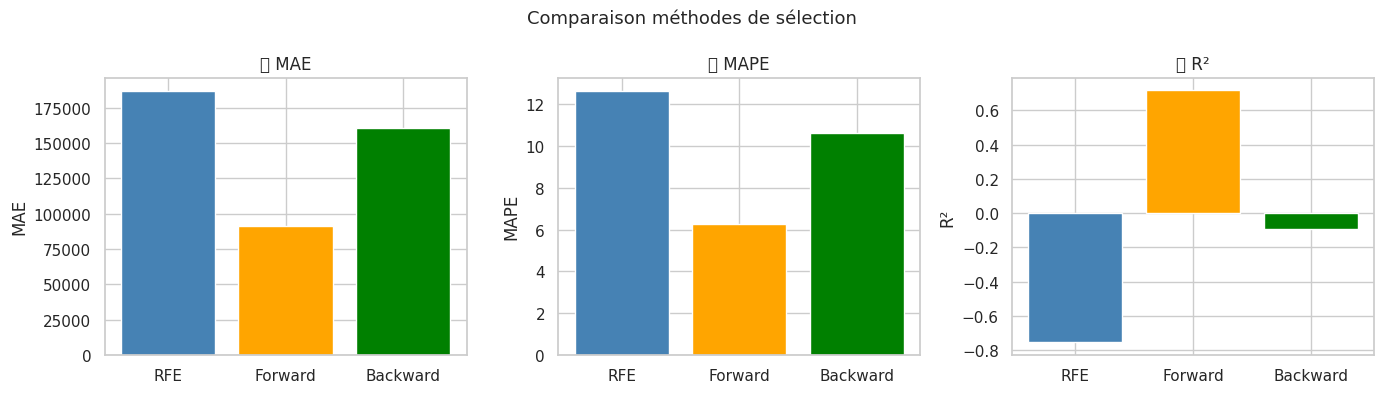

In [124]:
df_comp = pd.DataFrame([
    {'Méthode': 'RFE',      'MAE': mae_rfe,  'MAPE': mape_rfe,
     'R²': r2_rfe,  'Biais': bias_rfe,  'Features': features_rfe},
    {'Méthode': 'Forward',  'MAE': mae_fwd,  'MAPE': mape_fwd,
     'R²': r2_fwd,  'Biais': bias_fwd,  'Features': features_fwd},
    {'Méthode': 'Backward', 'MAE': mae_bwd,  'MAPE': mape_bwd,
     'R²': r2_bwd,  'Biais': bias_bwd,  'Features': features_bwd},
])

print("="*65)
print(f"{'Méthode':<12} {'MAE':>10} {'MAPE':>8} {'R²':>8} {'Biais':>12}")
print("="*65)
for _, row in df_comp.iterrows():
    print(f"{row['Méthode']:<12} {row['MAE']:>10,.0f} "
          f"{row['MAPE']:>7.2f}% {row['R²']:>8.4f} "
          f"{row['Biais']:>12,.0f} DT")
print("="*65)

# Graphe comparaison MAPE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'MAPE', 'R²']
for ax, metric in zip(axes, metrics):
    colors = ['steelblue', 'orange', 'green']
    ax.bar(df_comp['Méthode'], df_comp[metric], color=colors)
    ax.set_title(f'📊 {metric}')
    ax.set_ylabel(metric)
plt.suptitle('Comparaison méthodes de sélection', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Sélection de la meilleure méthode et sauvegarde

In [125]:
# Meilleure méthode selon MAPE
best_idx     = df_comp['MAPE'].idxmin()
best_method  = df_comp.loc[best_idx, 'Méthode']
best_features = df_comp.loc[best_idx, 'Features']
best_mape    = df_comp.loc[best_idx, 'MAPE']
best_mae     = df_comp.loc[best_idx, 'MAE']
best_r2      = df_comp.loc[best_idx, 'R²']

print(f"🏆 Meilleure méthode : {best_method}")
print(f"   MAPE     : {best_mape:.2f}%")
print(f"   MAE      : {best_mae:,.0f} DT")
print(f"   R²       : {best_r2:.4f}")
print(f"\n   Features ({len(best_features)}) :")
for f in best_features:
    print(f"     • {f}")

# Sauvegarder
df_ml.to_csv('/app/notebooks/ml_dataset_model_sel.csv', index=False)
with open('/app/notebooks/features_model_sel.json', 'w') as f:
    json.dump(best_features, f)

print(f"\n✅ Dataset sauvegardé → ml_dataset_model_sel.csv")
print(f"✅ Features sauvegardées → features_model_sel.json")

🏆 Meilleure méthode : Forward
   MAPE     : 6.25%
   MAE      : 91,480 DT
   R²       : 0.7171

   Features (8) :
     • year
     • quarter
     • is_end_year
     • is_january
     • lag_2
     • lag_6
     • rolling_mean_6
     • rolling_std_3

✅ Dataset sauvegardé → ml_dataset_model_sel.csv
✅ Features sauvegardées → features_model_sel.json
